# Avaliação de Teste A/B - Sistema de Recomendação Aprimorado

Autor: Fabrício Camacho

Data: 16/04/2026

## 1. Introdução e Contextualização
Este projeto consiste na análise de um teste A/B realizado por uma loja virtual internacional. O experimento, denominado `recommender_system_test`, foi projetado para avaliar o impacto da introdução de um sistema de recomendações aprimorado no comportamento de compra dos usuários.O teste foi iniciado por uma equipe anterior, mas não foi concluído. Nosso objetivo agora é processar os dados parciais, validar o rigor do desenho experimental e tirar conclusões estatisticamente fundamentadas sobre a eficácia do novo sistema.

## 2. Especificações do Teste
De acordo com a documentação técnica fornecida, os parâmetros do teste são os seguintes:
- **Nome do teste:** `recommender_system_test`;
- **Grupos:** Grupo A (Controle) e Grupo B (Novo funil de pagamento com sistema de recomendações);
- **Público-alvo:** $15\%$ dos novos usuários da região da União Europeia;
- **Número previsto de participantes:** $6.000$;
- **Datas importantes:**
    - Início da inscrição de novos usuários: 07/12/2020;
    - Término da inscrição de novos usuários: 21/12/2020;
    - Data de término do teste: 01/01/2021.

## 3. Objetivo e Hipóteses
O objetivo central é verificar se o novo sistema de recomendações melhora a conversão dos usuários em cada etapa do funil de vendas nos primeiros $14$ dias após a inscrição.

**Resultado esperado:**

Espera-se um aumento mínimo de $10\%$ na taxa de conversão para cada uma das seguintes etapas:
1. Visualização da página de produto (`product_page`);
2. Adição de itens ao carrinho (`product_card`);
3. Finalização da compra (`purchase`).

## 4. Descrição dos Dados
Para esta análise, utilizaremos quatro conjuntos de dados. Abaixo está a descrição da estrutura de cada um deles:
1. `ab_project_marketing_events_us.csv` (Calendário de eventos de marketing de 2020):
    - `name`: nome do evento de marketing;
    - `regions`: regiões onde a campanha será realizada;
    - `start_dt`: data de início;
    - `finish_dt`: data de término.
2. `final_ab_new_users_upd_us.csv` (Dados de usuários registrados no período do teste):
    - `user_id`: ID único do cliente;
    - `first_date`: data de inscrição;
    - `region`: região do usuário;
    - `device`: dispositivo utilizado.
3. `final_ab_events_upd_us.csv` (Eventos realizados pelos novos usuários):
    - `user_id`: ID único do cliente;
    - `event_dt`: data e hora do evento;
    - `event_name`: nome do tipo de evento;
    - `details`: informações adicionais (por exemplo, valor total do pedido na etapa de `purchase`).
4. `final_ab_participants_upd_us.csv` (Lista de participantes e seus respectivos grupos de teste):
    - `user_id`: ID único do cliente;
    - `ab_test`: nome do experimento;
    - `group`: grupo ao qual o usuário pertence.

## 5. Preparação e Diagnóstico Inicial dos Dados
Nesta etapa, importaremos as bibliotecas essenciais para a manipulação dos dados, visualização e para a futura análise estatística. 

Na sequência, faremos o carregamento dos arquivos CSV fornecidos e aplicaremos uma função de inspeção. O objetivo deste diagnóstico inicial é entender os tipos de variáveis e identificar rapidamente a necessidade de tratamento de valores ausentes, duplicados ou conversão de tipos (como datas).

In [10]:
# Importação das bibliotecas necessárias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import seaborn as sns
from scipy import stats
import math
import warnings
warnings.filterwarnings('ignore') # Ignora avisos não críticos para manter o notebook limpo

# Configurações de estilo para deixar os gráficos mais agradáveis visualmente
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Carregamento dos dados
# Nota: Certifique-se de que os arquivos CSV estão no mesmo diretório deste notebook.
try:
    marketing_events = pd.read_csv('datasets/ab_project_marketing_events_us.csv')
    new_users = pd.read_csv('datasets/final_ab_new_users_upd_us.csv')
    events = pd.read_csv('datasets/final_ab_events_upd_us.csv')
    participants = pd.read_csv('datasets/final_ab_participants_upd_us.csv')
    print("Todos os 4 arquivos foram carregados com sucesso!")
except FileNotFoundError as e:
    print(f"Erro ao carregar os arquivos: {e}")
    print("Verifique se os arquivos estão na mesma pasta do seu Jupyter Notebook.")
    

Todos os 4 arquivos foram carregados com sucesso!


In [11]:
# Criando um dicionário com os DataFrames para facilitar a iteração
datasets = {
    'Eventos de Marketing': marketing_events,
    'Novos Usuários': new_users,
    'Eventos dos Usuários': events,
    'Participantes do Teste A/B': participants
}

# Função para inspecionar os dados iniciais
def inspect_data(df, name):
    print(f"\n{'='*50}")
    print(f"--- Informações do Dataset: {name} ---")
    print(f"{'='*50}")
    df.info()
    print("\nVisualização das primeiras linhas:")
    display(df.head(3))

# Aplicando a função em todos os nossos DataFrames
for name, data in datasets.items():
    inspect_data(data, name)
    


--- Informações do Dataset: Eventos de Marketing ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   name       14 non-null     object
 1   regions    14 non-null     object
 2   start_dt   14 non-null     object
 3   finish_dt  14 non-null     object
dtypes: object(4)
memory usage: 580.0+ bytes

Visualização das primeiras linhas:


,name,regions,start_dt,finish_dt
0,Christmas&New Year Promo,"EU, N.America",2020-12-25,2021-01-03
1,St. Valentine's Day Giveaway,"EU, CIS, APAC, N.America",2020-02-14,2020-02-16
2,St. Patric's Day Promo,"EU, N.America",2020-03-17,2020-03-19



--- Informações do Dataset: Novos Usuários ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58703 entries, 0 to 58702
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     58703 non-null  object
 1   first_date  58703 non-null  object
 2   region      58703 non-null  object
 3   device      58703 non-null  object
dtypes: object(4)
memory usage: 1.8+ MB

Visualização das primeiras linhas:


,user_id,first_date,region,device
0,D72A72121175D8BE,2020-12-07,EU,PC
1,F1C668619DFE6E65,2020-12-07,N.America,Android
2,2E1BF1D4C37EA01F,2020-12-07,EU,PC



--- Informações do Dataset: Eventos dos Usuários ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 423761 entries, 0 to 423760
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   user_id     423761 non-null  object 
 1   event_dt    423761 non-null  object 
 2   event_name  423761 non-null  object 
 3   details     60314 non-null   float64
dtypes: float64(1), object(3)
memory usage: 12.9+ MB

Visualização das primeiras linhas:


,user_id,event_dt,event_name,details
0,E1BDDCE0DAFA2679,2020-12-07 20:22:03,purchase,99.99
1,7B6452F081F49504,2020-12-07 09:22:53,purchase,9.99
2,9CD9F34546DF254C,2020-12-07 12:59:29,purchase,4.99



--- Informações do Dataset: Participantes do Teste A/B ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14525 entries, 0 to 14524
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   user_id  14525 non-null  object
 1   group    14525 non-null  object
 2   ab_test  14525 non-null  object
dtypes: object(3)
memory usage: 340.6+ KB

Visualização das primeiras linhas:


,user_id,group,ab_test
0,D1ABA3E2887B6A73,A,recommender_system_test
1,A7A3664BD6242119,A,recommender_system_test
2,DABC14FDDFADD29E,A,recommender_system_test


**Observações:** Com base no diagnóstico inicial, observamos que:
- **Tipos de Dados:** As colunas que armazenam informações de data e hora estão no formato `object` (string). Vamos convertê-las para o formato `datetime` do pandas para permitir análises temporais;
- **Valores Ausentes:** A coluna `details` no dataframe de eventos possui muitos valores nulos. Isso é um comportamento esperado, pois essa coluna registra o valor financeiro de um pedido. Portanto, apenas o evento de `purchase` (compra) deve possuir essa coluna preenchida. Manteremos os valores ausentes (`NaN`) intactos, pois substituí-los por zero poderia distorcer futuras análises financeiras;
- **Duplicatas:** Executaremos uma verificação de linhas inteiramente duplicadas em todos os conjuntos de dados.


In [12]:
# Conversão dos tipos de dados para datetime
marketing_events['start_dt'] = pd.to_datetime(marketing_events['start_dt'])
marketing_events['finish_dt'] = pd.to_datetime(marketing_events['finish_dt'])

new_users['first_date'] = pd.to_datetime(new_users['first_date'])

events['event_dt'] = pd.to_datetime(events['event_dt'])

print("Conversão de datas realizada com sucesso!")

# Verificação de valores duplicados (linhas exatas)
print("\nVerificação de Linhas Duplicadas:")
print(f"Eventos de Marketing: {marketing_events.duplicated().sum()}")
print(f"Novos Usuários: {new_users.duplicated().sum()}")
print(f"Eventos dos Usuários: {events.duplicated().sum()}")
print(f"Participantes do Teste: {participants.duplicated().sum()}")

# Validando a teoria sobre os valores ausentes em 'details'
print("\nValidando valores ausentes em 'details':")
purchase_events = events[events['event_name'] == 'purchase']
print(f"Total de eventos de 'purchase': {len(purchase_events)}")
print(f"Total de valores preenchidos em 'details': {events['details'].notna().sum()}")


Conversão de datas realizada com sucesso!

Verificação de Linhas Duplicadas:
Eventos de Marketing: 0
Novos Usuários: 0
Eventos dos Usuários: 0
Participantes do Teste: 0

Validando valores ausentes em 'details':
Total de eventos de 'purchase': 60314
Total de valores preenchidos em 'details': 60314


**Observações:** Após a execução das verificações, confirmamos a integridade dos dados:
- **Ausência de Duplicatas:** Não encontramos nenhuma linha inteiramente duplicada em nenhum dos quatro conjuntos de dados.
- **Valores Ausentes Explicados:** Comprovamos a nossa hipótese sobre a coluna `details`. O sistema registrou 60.314 eventos do tipo `purchase` (compra), que é exatamente o mesmo número de valores preenchidos na coluna `details`. Isso atesta que os valores nulos (`NaN`) não são dados perdidos, mas sim um registro natural de eventos que não geram receita (como visualização da página ou adição ao carrinho).

Com os dados limpos e as datas devidamente convertidas para `datetime`, nossa base está pronta e confiável para iniciarmos a avaliação do teste.

## 6. Avaliação do Desenho Experimental
Antes de analisarmos as métricas, precisamos garantir que o teste foi configurado corretamente. Nossos dados contêm informações gerais, mas nosso foco é exclusivo no teste `recommender_system_test`.

Vamos verificar:
1. Quantos usuários estão alocados neste teste específico;
2. Se existem usuários que caíram acidentalmente em ambos os grupos (A e B), o que invalidaria a experiência deles.

In [13]:
# Filtrando apenas os participantes do teste 'recommender_system_test'
recommender_participants = participants[participants['ab_test'] == 'recommender_system_test']
print(f"Total de participantes no teste 'recommender_system_test': {len(recommender_participants)}")

# Verificando a distribuição nos grupos A e B
print("\nDistribuição dos usuários por grupo:")
print(recommender_participants['group'].value_counts())

# Verificando se há usuários em ambos os grupos (interseção)
group_a_users = set(recommender_participants[recommender_participants['group'] == 'A']['user_id'])
group_b_users = set(recommender_participants[recommender_participants['group'] == 'B']['user_id'])

# A interseção entre os dois conjuntos revelará quem está nos dois grupos ao mesmo tempo
overlapping_users = group_a_users.intersection(group_b_users)

print(f"\nUsuários presentes em AMBOS os grupos (A e B): {len(overlapping_users)}")

# Removendo usuários sobrepostos (se houver) para não contaminar o teste
if len(overlapping_users) > 0:
    recommender_participants = recommender_participants[~recommender_participants['user_id'].isin(overlapping_users)]
    print(f"Usuários sobrepostos removidos. Novo total de participantes: {len(recommender_participants)}")
    

Total de participantes no teste 'recommender_system_test': 3675

Distribuição dos usuários por grupo:
group
A    2747
B     928
Name: count, dtype: int64

Usuários presentes em AMBOS os grupos (A e B): 0


**Observações:** Ao analisarmos a distribuição de participantes do teste `recommender_system_test`, identificamos inconsistências graves em relação às especificações técnicas originais:
- **Tamanho da Amostra Inferior ao Esperado:** O planejamento previa $6.000$ participantes, mas o teste conta com apenas $3.675$ usuários alocados;
- **Desequilíbrio Severo entre os Grupos:** A proporção entre os grupos está altamente distorcida. O Grupo A (Controle) possui $2.747$ usuários, enquanto o Grupo B (Teste) possui apenas $928$. Essa assimetria pode comprometer a validade estatística e a confiabilidade dos resultados;
- **Ausência de Sobreposição:** Como ponto positivo, verificamos que não há usuários presentes em ambos os grupos simultaneamente, garantindo que não há contaminação cruzada direta nesse aspecto.

### 6.1 Validação da Região e Regra dos $15\%$
A documentação do teste especifica que a audiência deve ser composta por 15% dos novos usuários da região da União Europeia (EU). 

Para validar isso, faremos um `merge` (junção) da tabela de participantes do nosso teste com a tabela de novos usuários (`new_users`). Em seguida, verificaremos as regiões e calcularemos a proporção exata de usuários da EU que foram incluídos no experimento.


In [14]:
# Juntando os dados dos participantes com os dados de cadastro (new_users)
# Usamos how='left' para garantir que manteremos todos os participantes do teste
test_users_info = recommender_participants.merge(new_users, on='user_id', how='left')

# Verificando as regiões dos participantes
print("Distribuição de regiões dos participantes do teste:")
print(test_users_info['region'].value_counts())

# Calculando a proporção de usuários da EU
# Precisamos do total geral de novos usuários da EU cadastrados na tabela original
total_eu_new_users = new_users[new_users['region'] == 'EU']['user_id'].nunique()

# E quantos desses entraram no nosso teste
test_eu_users = test_users_info[test_users_info['region'] == 'EU']['user_id'].nunique()

# Calculando a porcentagem
eu_percentage = (test_eu_users / total_eu_new_users) * 100

print(f"\n--- Verificação da Meta de 15% ---")
print(f"Total de novos usuários da EU cadastrados no período: {total_eu_new_users}")
print(f"Participantes da EU alocados no teste: {test_eu_users}")
print(f"Proporção alcançada: {eu_percentage:.2f}%")


Distribuição de regiões dos participantes do teste:
region
EU           3481
N.America     119
APAC           45
CIS            30
Name: count, dtype: int64

--- Verificação da Meta de 15% ---
Total de novos usuários da EU cadastrados no período: 43396
Participantes da EU alocados no teste: 3481
Proporção alcançada: 8.02%


**Observações:** A análise da distribuição regional dos participantes revelou mais duas limitações severas no desenho do experimento:
- **Infiltração de Usuários de Outras Regiões:** O teste deveria ser focado em usuários da região da União Europeia. Contudo, identificamos 194 participantes de outras regiões (América do Norte, APAC e CIS). Para garantir a integridade da análise, esses usuários não farão parte do estudo principal, visto que o comportamento de consumo pode variar geograficamente;
- **Falha na Meta de Audiência:** A especificação exigia a participação de $15\%$ dos novos usuários da região da União Europeia. No entanto, o teste capturou apenas $8,02\%$ ($3.481$ de $43.396$). Essa quebra na meta agrava o problema do tamanho reduzido da amostra, o que diminui a sensibilidade do teste para detectar mudanças reais.


In [15]:
# Removendo os usuários que não são da União Europeia
test_users_eu = test_users_info[test_users_info['region'] == 'EU']

print(f"Total de participantes após filtrar apenas a região EU: {len(test_users_eu)}")

# Verificando como ficou a divisão dos grupos após essa limpeza
print("\nNova distribuição dos grupos (Apenas EU):")
print(test_users_eu['group'].value_counts())


Total de participantes após filtrar apenas a região EU: 3481

Nova distribuição dos grupos (Apenas EU):
group
A    2604
B     877
Name: count, dtype: int64


**Observações:** Após a remoção dos usuários fora da União Europeia, nossa amostra final de análise caiu para $3.481$ participantes. É importante notar que o filtro não corrigiu a assimetria entre os grupos de teste: o Grupo A (Controle) manteve a esmagadora maioria com $2.604$ usuários, enquanto o Grupo B (Teste) ficou com apenas $877$. Essa limitação persistirá por toda a análise e deve ser considerada ao interpretarmos a significância estatística dos resultados finais.

### 6.2 Análise de Fatores de Confusão (Campanhas de Marketing)
Para garantir que as variações nas taxas de conversão sejam exclusivas da mudança do sistema de recomendações, precisamos verificar se houve sobreposição de eventos de marketing na região da União Europeia durante o período do teste (07/12/2020 a 01/01/2021). Campanhas promocionais simultâneas podem atuar como fatores de confusão, impulsionando compras de forma artificial.


In [16]:
# Definindo o período do nosso teste A/B
test_start = pd.to_datetime('2020-12-07')
test_end = pd.to_datetime('2021-01-01')

# Filtrando campanhas que englobam a região 'EU'
eu_campaigns = marketing_events[marketing_events['regions'].str.contains('EU')]

# Verificando sobreposição de datas
# Uma campanha sobrepõe o teste se ela começa antes do teste terminar E termina depois do teste começar
overlapping_campaigns = eu_campaigns[
    (eu_campaigns['start_dt'] <= test_end) & 
    (eu_campaigns['finish_dt'] >= test_start)
]

print("Campanhas de marketing na EU ativas durante o período do teste A/B:")
display(overlapping_campaigns)


Campanhas de marketing na EU ativas durante o período do teste A/B:


,name,regions,start_dt,finish_dt
0,Christmas&New Year Promo,"EU, N.America",2020-12-25,2021-01-03


**Observações:** Nossa avaliação rigorosa do desenho do experimento revelou múltiplas falhas graves na execução pela equipe anterior:
1. **Amostra Insuficiente:** Não atingimos a cota de $15\%$ de novos usuários da EU nem a meta de $6.000$ participantes;
2. **Desequilíbrio de Grupos:** O Grupo A tem o triplo do tamanho do Grupo B, o que afeta o poder estatístico;
3. **Fator de Confusão (Interferência Externa):** Identificamos que a campanha *Christmas&New Year Promo* ocorreu na região da União Europeia entre 25/12/2020 e 03/01/2021. Essa sobreposição com os últimos dias do teste injeta "ruído" nos dados, pois um eventual aumento na conversão nesse período pode estar atrelado ao comportamento sazonal de Natal e não à eficácia do sistema de recomendações.

Apesar de todas essas limitações reduzirem a precisão do estudo, não há usuários sobrepostos nos grupos, o que nos permite prosseguir com a Análise Exploratória e os Testes Estatísticos, mantendo essas ressalvas em mente.

## 7. Análise Exploratória de Dados (AED)
Com nossa amostra isolada e validada (usuários da EU), vamos investigar o comportamento deles dentro do site. Os principais pontos que analisaremos são:
1. O número de eventos por usuário está distribuído de forma equilibrada entre as amostras?
2. Como os eventos estão distribuídos ao longo dos dias e será que vemos o impacto da promoção de Natal?


Resumo estatístico do número de eventos por usuário em cada grupo:


,count,mean,std,min,25%,50%,75%,max
group,,,,,,,,
A,2604.0,6.785714,3.733456,1.0,4.0,6.0,9.0,24.0
B,877.0,5.705815,3.455540,1.0,3.0,5.0,8.0,28.0


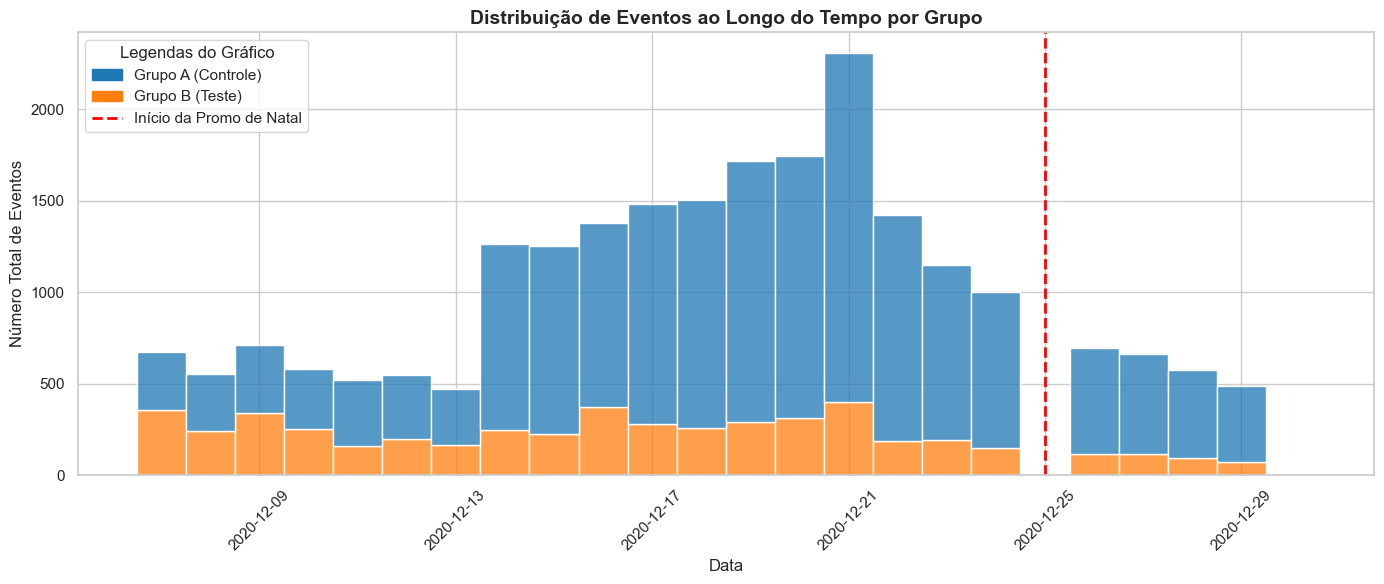

In [17]:
# Filtrando a tabela de eventos apenas para os usuários válidos do nosso teste (UE)
valid_users = test_users_eu[['user_id', 'group']]
test_events = events.merge(valid_users, on='user_id', how='inner')

# Média de eventos por usuário em cada grupo
events_per_user = test_events.groupby(['group', 'user_id']).size().reset_index(name='event_count')

print("Resumo estatístico do número de eventos por usuário em cada grupo:")
display(events_per_user.groupby('group')['event_count'].describe())

# Visualização: Distribuição de eventos ao longo dos dias
plt.figure(figsize=(14, 6))
test_events['date'] = test_events['event_dt'].dt.date

# Definindo cores fixas para os grupos
cores_grupos = {'A': '#1f77b4', 'B': '#ff7f0e'} # Azul para Grupo A, Laranja para Grupo B

# Criando o gráfico
sns.histplot(data=test_events, x='date', hue='group', multiple='stack', 
             palette=cores_grupos, bins=len(test_events['date'].unique()))

plt.title('Distribuição de Eventos ao Longo do Tempo por Grupo', fontsize=14, fontweight='bold')
plt.xlabel('Data', fontsize=12)
plt.ylabel('Número Total de Eventos', fontsize=12)
plt.xticks(rotation=45)

# Linha da promoção de Natal
plt.axvline(pd.to_datetime('2020-12-25'), color='red', linestyle='--', linewidth=2)

# Criando os itens da legenda manualmente para garantir clareza
patch_A = mpatches.Patch(color='#1f77b4', label='Grupo A (Controle)')
patch_B = mpatches.Patch(color='#ff7f0e', label='Grupo B (Teste)')
linha_promo = mlines.Line2D([], [], color='red', linestyle='--', linewidth=2, label='Início da Promo de Natal')

# Adicionando a legenda ao gráfico
plt.legend(handles=[patch_A, patch_B, linha_promo], title='Legendas do Gráfico', loc='upper left', frameon=True)

plt.tight_layout()
plt.show()
